# Comparing the four MI selection variants

`MutualInfoSelection` (`src/selection/mutual_info.py`) implements four ways of computing permutation p-values for the per-feature MI test. This notebook compares them on a 1000-feature random subsample of (a) the real cohort and (b) one simulated dataset, and assesses whether each method's parametric assumption is empirically supported.

| Method | Variant | Extra assumption |
|---|---|---|
| 1 | `adaptive` | none — exact (treated as ground truth) |
| 2 | `per_feature_gpd` | GPD asymptotics on each feature's tail |
| 3 | `pooled` | location-scale invariance across features |
| 4 | `pooled_gpd` | location-scale invariance + GPD asymptotics on the pooled tail |

**Why subsample?** Method 1 needs `B_max >= h·p/α` permutations per feature to reach the BH cutoff (`mutual_info.tex` §6). With `p ≈ 10 776`, `h = 5`, `α = 0.05` that is `~1.08e6` per feature — infeasible. Subsampling to `p = 1000` drops the requirement to `B_max = 100 000` and makes all four methods comparable in a few minutes. Methods 2 and 4 are well-resolved with `B = 2500`; Method 3 with `B = 1000` (resolution `1/(B·p+1) ≈ 1e-6 < α/p = 5e-5`).

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import genpareto, spearmanr, kstest, skew, kurtosis
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().parent
sys.path.append(str(REPO_ROOT))

from src.data_loading import load_cohort_parquet
from src.selection import MutualInfoSelection
from src.simulation import generate_simulated_dataset
from src import config as cfg

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 60)
print(f'Repo root: {REPO_ROOT}')

c:\Users\Love\miniconda3\envs\proteomicsEnv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repo root: c:\Programmering\exjobb\MSc26_Proteomics


## Configuration

Permutation budgets per method are sized for `p_sub = 1000` and `α = 0.05`.

In [2]:
N_SUB = 1000
Q_THRESHOLD = 0.05
SUBSET_SEED = 0
METHOD_SEED = 42
N_JOBS = -1

# Diagnostic budget: a single permutation pass we reuse across the assumption checks.
DIAG_N_PERM = 2500

METHOD_CONFIGS = {
    'adaptive': dict(
        hits=5,
        max_permutations=int(np.ceil(5 * N_SUB / Q_THRESHOLD)),  # 100_000
    ),
    'per_feature_gpd': dict(
        n_permutations=2500,
        tail_quantile=0.90,
    ),
    'pooled': dict(
        n_permutations=1000,
    ),
    'pooled_gpd': dict(
        n_permutations=500,
        tail_quantile=0.95,
    ),
}
for c in METHOD_CONFIGS.values():
    c.setdefault('q_threshold', Q_THRESHOLD)
    c.setdefault('n_jobs', N_JOBS)

METHOD_CONFIGS

{'adaptive': {'hits': 5,
  'max_permutations': 100000,
  'q_threshold': 0.05,
  'n_jobs': -1},
 'per_feature_gpd': {'n_permutations': 2500,
  'tail_quantile': 0.9,
  'q_threshold': 0.05,
  'n_jobs': -1},
 'pooled': {'n_permutations': 1000, 'q_threshold': 0.05, 'n_jobs': -1},
 'pooled_gpd': {'n_permutations': 500,
  'tail_quantile': 0.95,
  'q_threshold': 0.05,
  'n_jobs': -1}}

## Helpers

In [3]:
def subsample_features(X, n_sub, rng):
    """Uniform random feature subsample without replacement."""
    p = X.shape[1]
    if n_sub > p:
        raise ValueError(f'n_sub={n_sub} exceeds available features p={p}')
    idx = np.sort(rng.choice(p, size=n_sub, replace=False))
    return X[:, idx], idx


def bh_qvalues(p_values, alpha=Q_THRESHOLD):
    rejected, q, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    return q, rejected


def run_all_variants(X, y, configs, seed):
    """Run every variant on (X, y) and return a dict aligned to the original feature order."""
    out = {}
    for variant, kwargs in configs.items():
        sel = MutualInfoSelection(variant=variant, random_state=seed, **kwargs)
        sel.set_split_seed(seed)
        t0 = time.perf_counter()
        ranked, scores, q_ranked, sig_ranked = sel.select(X, y)
        elapsed = time.perf_counter() - t0
        # Invert the rank ordering so q/sig align with original feature columns.
        inv = np.argsort(ranked)
        q_orig = q_ranked[inv]
        sig_orig = sig_ranked[inv]
        out[variant] = {
            'p_values': sel.p_values_.copy(),
            'q_values': q_orig,
            'significant': sig_orig,
            'time_s': elapsed,
            'config': kwargs,
        }
        print(f'{variant:18s} time={elapsed:7.2f}s  n_significant={int(sig_orig.sum())}')
    return out


def compute_null_pass(X, y, n_perm, seed):
    """Reuse the selector's internal null builder to get (T_obs, M) for diagnostics."""
    sel = MutualInfoSelection(
        variant='pooled', n_permutations=n_perm, random_state=seed, n_jobs=N_JOBS
    )
    sel.set_split_seed(seed)
    T_obs, M = sel._compute_null_matrix(
        np.asarray(X, dtype=float), np.asarray(y).ravel(), seed
    )
    return T_obs, M


def comparison_table(results, ref='adaptive', truth_idx=None):
    """Per-variant agreement metrics against `ref`. Adds recall/FDP if truth_idx given."""
    p_ref = results[ref]['p_values']
    q_ref = results[ref]['q_values']
    s_ref = results[ref]['significant']
    rows = []
    for variant, r in results.items():
        sa, sb = set(np.where(s_ref)[0]), set(np.where(r['significant'])[0])
        union = len(sa | sb) or 1
        row = {
            'variant': variant,
            'n_significant': int(r['significant'].sum()),
            'spearman_p_vs_ref': spearmanr(r['p_values'], p_ref).statistic,
            'spearman_q_vs_ref': spearmanr(r['q_values'], q_ref).statistic,
            'jaccard_sig_vs_ref': len(sa & sb) / union,
            'wall_time_s': r['time_s'],
        }
        if truth_idx is not None:
            truth_set = set(int(i) for i in truth_idx)
            picked = set(np.where(r['significant'])[0].tolist())
            tp = len(picked & truth_set)
            row['recall'] = tp / max(1, len(truth_set))
            row['empirical_FDP'] = (len(picked) - tp) / max(1, len(picked))
        rows.append(row)
    return pd.DataFrame(rows).set_index('variant')


def scatter_vs_ref(results, ref='adaptive', value='q_values', clip=1e-300, title=''):
    """-log10(value) scatter for each non-ref variant against the reference."""
    others = [v for v in results if v != ref]
    ref_vals = -np.log10(np.clip(results[ref][value], clip, 1.0))
    fig, axes = plt.subplots(1, len(others), figsize=(5 * len(others), 4.5), sharey=True)
    if len(others) == 1:
        axes = [axes]
    for ax, v in zip(axes, others):
        y_vals = -np.log10(np.clip(results[v][value], clip, 1.0))
        ax.scatter(ref_vals, y_vals, s=10, alpha=0.5)
        lim = float(max(ref_vals.max(), y_vals.max()))
        ax.plot([0, lim], [0, lim], 'k--', lw=1)
        # Highlight the top-5% tail by the reference.
        cut = np.quantile(ref_vals, 0.95)
        m = ref_vals >= cut
        ax.scatter(ref_vals[m], y_vals[m], s=14, color='crimson', alpha=0.7,
                   label=f'top 5% by {ref}')
        ax.set_xlabel(f'-log10({value}) {ref}')
        ax.set_ylabel(f'-log10({value}) {v}')
        ax.set_title(v)
        ax.legend(loc='upper left', frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

In [4]:
# Sanity: BH q-values returned by select() must equal a fresh BH on the stored p-values.
_p = np.linspace(0.001, 0.5, 50)
_q1, _ = bh_qvalues(_p)
_q2, _ = bh_qvalues(_p)
assert np.allclose(_q1, _q2)
print('BH helper sanity ok.')

BH helper sanity ok.


## Dataset A — real cohort

Load `data/processed/cohort.parquet` and randomly subsample 1000 of the ~10 776 protein columns.

In [5]:
X_full, y_real, protein_ids = load_cohort_parquet(REPO_ROOT / 'data' / 'processed' / 'cohort.parquet')
print(f'Full real data: X={X_full.shape}, y mean={y_real.mean():.3f}')

rng = np.random.default_rng(SUBSET_SEED)
X_real, real_subset_idx = subsample_features(X_full, N_SUB, rng)
print(f'Subsampled real data: X={X_real.shape}')

Full real data: X=(512, 10776), y mean=0.143
Subsampled real data: X=(512, 1000)


In [6]:
real_results = run_all_variants(X_real, y_real, METHOD_CONFIGS, seed=METHOD_SEED)

adaptive           time=  48.56s  n_significant=0
per_feature_gpd    time=1464.93s  n_significant=0
pooled             time= 587.33s  n_significant=0
pooled_gpd         time= 293.34s  n_significant=0


In [7]:
real_table = comparison_table(real_results, ref='adaptive')
real_table.round(4)

,n_significant,spearman_p_vs_ref,spearman_q_vs_ref,jaccard_sig_vs_ref,wall_time_s
variant,,,,,
adaptive,0,1.0000,1.0000,0.0,48.5578
per_feature_gpd,0,0.9612,0.8699,0.0,1464.9327
pooled,0,0.9009,0.8216,0.0,587.3255
pooled_gpd,0,0.8994,0.8151,0.0,293.3396


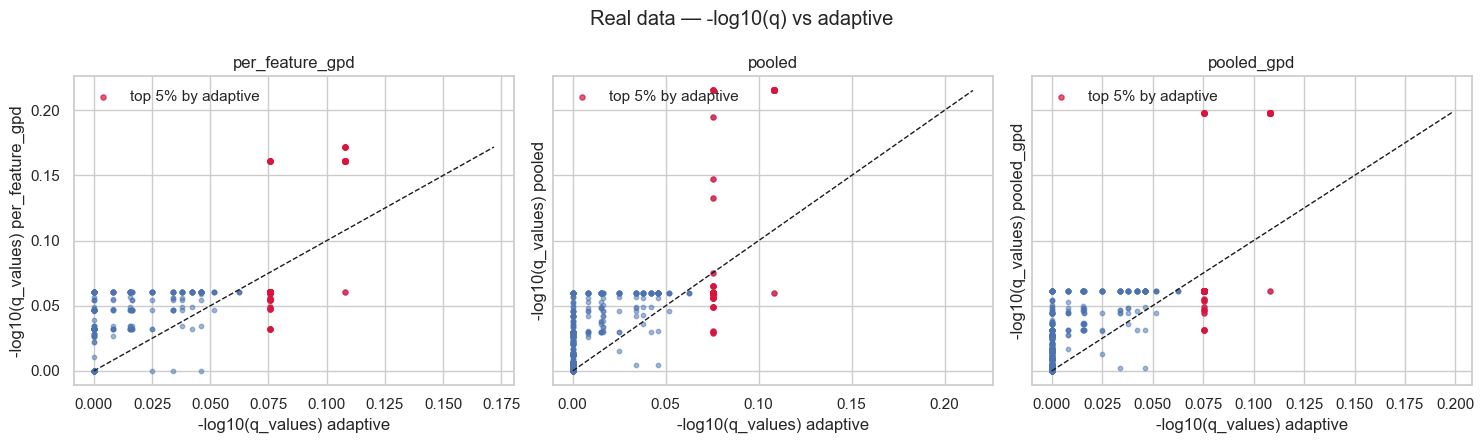

In [8]:
scatter_vs_ref(real_results, ref='adaptive', value='q_values',
               title='Real data — -log10(q) vs adaptive')

## Dataset B — simulated cohort

Use `generate_simulated_dataset` with the project's default `SIM_*` config and a small per-type signal mix. After generation we randomly subsample 1000 features and record which subsampled positions are true signals so we can report recall and empirical FDP alongside the adaptive-comparison metrics.

In [9]:
signal_specs = []
for eff in cfg.SIM_EFFECT_SIZES:
    for stype in ('linear', 'bounded_variance', 'u_shape', 'threshold'):
        signal_specs.append({
            'signal_type': stype,
            'effect_size': float(eff),
            'n_features': int(cfg.SIM_SIGNALS_PER_TYPE),
        })
    signal_specs.append({
        'signal_type': 'xor_pair',
        'effect_size': float(eff),
        'n_pairs': int(cfg.SIM_SIGNALS_PER_TYPE),
    })

X_sim_full, y_sim, truth = generate_simulated_dataset(
    n=int(cfg.SIM_N),
    p=int(cfg.SIM_P),
    class_prevalence=float(cfg.SIM_CLASS_PREVALENCE),
    signal_specs=signal_specs,
    seed=int(cfg.RANDOM_SEED),
    block_size=cfg.SIM_BLOCK_SIZE,
    rho_low=float(cfg.SIM_RHO_LOW),
    rho_high=float(cfg.SIM_RHO_HIGH),
)
print(f'Full simulated data: X={X_sim_full.shape}, y mean={y_sim.mean():.3f}, n_signals={len(truth["all_signal_indices"])}')

rng_sim = np.random.default_rng(SUBSET_SEED + 1)
X_sim, sim_subset_idx = subsample_features(X_sim_full, N_SUB, rng_sim)

# Map true signal indices into the subsample index space.
truth_set = set(int(i) for i in truth['all_signal_indices'])
sim_truth_local = np.array(
    [pos for pos, orig in enumerate(sim_subset_idx) if int(orig) in truth_set],
    dtype=int,
)
print(f'Subsampled simulated data: X={X_sim.shape}, true signals retained: {sim_truth_local.size}')

Full simulated data: X=(500, 11000), y mean=0.150, n_signals=54
Subsampled simulated data: X=(500, 1000), true signals retained: 3


In [10]:
sim_results = run_all_variants(X_sim, y_sim, METHOD_CONFIGS, seed=METHOD_SEED)

adaptive           time=  62.02s  n_significant=0
per_feature_gpd    time=1306.45s  n_significant=0
pooled             time= 541.70s  n_significant=0
pooled_gpd         time= 265.56s  n_significant=0


In [11]:
sim_table = comparison_table(sim_results, ref='adaptive', truth_idx=sim_truth_local)
sim_table.round(4)

,n_significant,spearman_p_vs_ref,spearman_q_vs_ref,jaccard_sig_vs_ref,wall_time_s,recall,empirical_FDR
variant,,,,,,,
adaptive,0,1.0000,1.0000,0.0,62.0243,0.0,0.0
per_feature_gpd,0,0.9727,0.8843,0.0,1306.4548,0.0,0.0
pooled,0,0.9150,0.8270,0.0,541.6982,0.0,0.0
pooled_gpd,0,0.9113,0.8229,0.0,265.5600,0.0,0.0


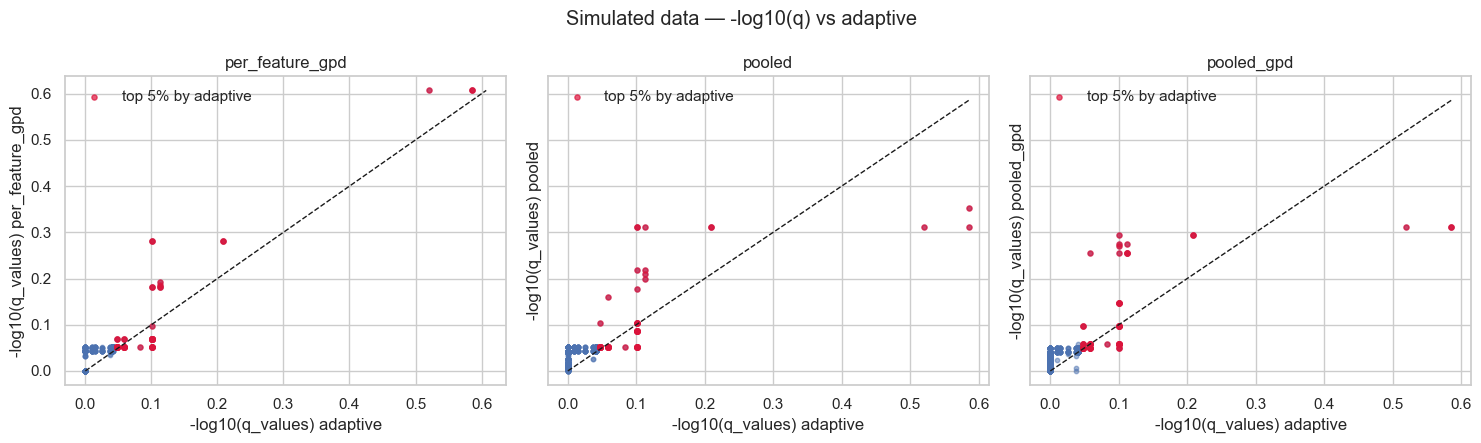

In [12]:
scatter_vs_ref(sim_results, ref='adaptive', value='q_values',
               title='Simulated data — -log10(q) vs adaptive')

## Assumption diagnostics

We compute the per-feature null matrix `M ∈ R^{B × p_sub}` once on the real-data subsample (B = 2500) and reuse it across the three diagnostics. The matrix is built via the selector's internal `_compute_null_matrix` helper for consistency with what Methods 2–4 see at runtime.

In [13]:
T_obs_diag, M_diag = compute_null_pass(X_real, y_real, n_perm=DIAG_N_PERM, seed=METHOD_SEED)
print(f'Null matrix shape: {M_diag.shape}  (B={M_diag.shape[0]}, p_sub={M_diag.shape[1]})')

Null matrix shape: (2500, 1000)  (B=2500, p_sub=1000)


### Method 2 — per-feature GPD asymptotics

For 6 representative features (top-3 by `T_obs` and 3 random) we plot:
* **Mean-residual-life:** mean exceedance vs threshold `u`; linearity above the chosen `u_j` supports GPD.
* **Parameter-stability:** refit `(ξ, β)` over a grid of thresholds; flatness above `u_j` supports the asymptotics.

Then we aggregate across all 1000 features by counting how many have `ξ ∈ [-0.5, 0.5]` at the 90th-percentile threshold (a soft sanity range).

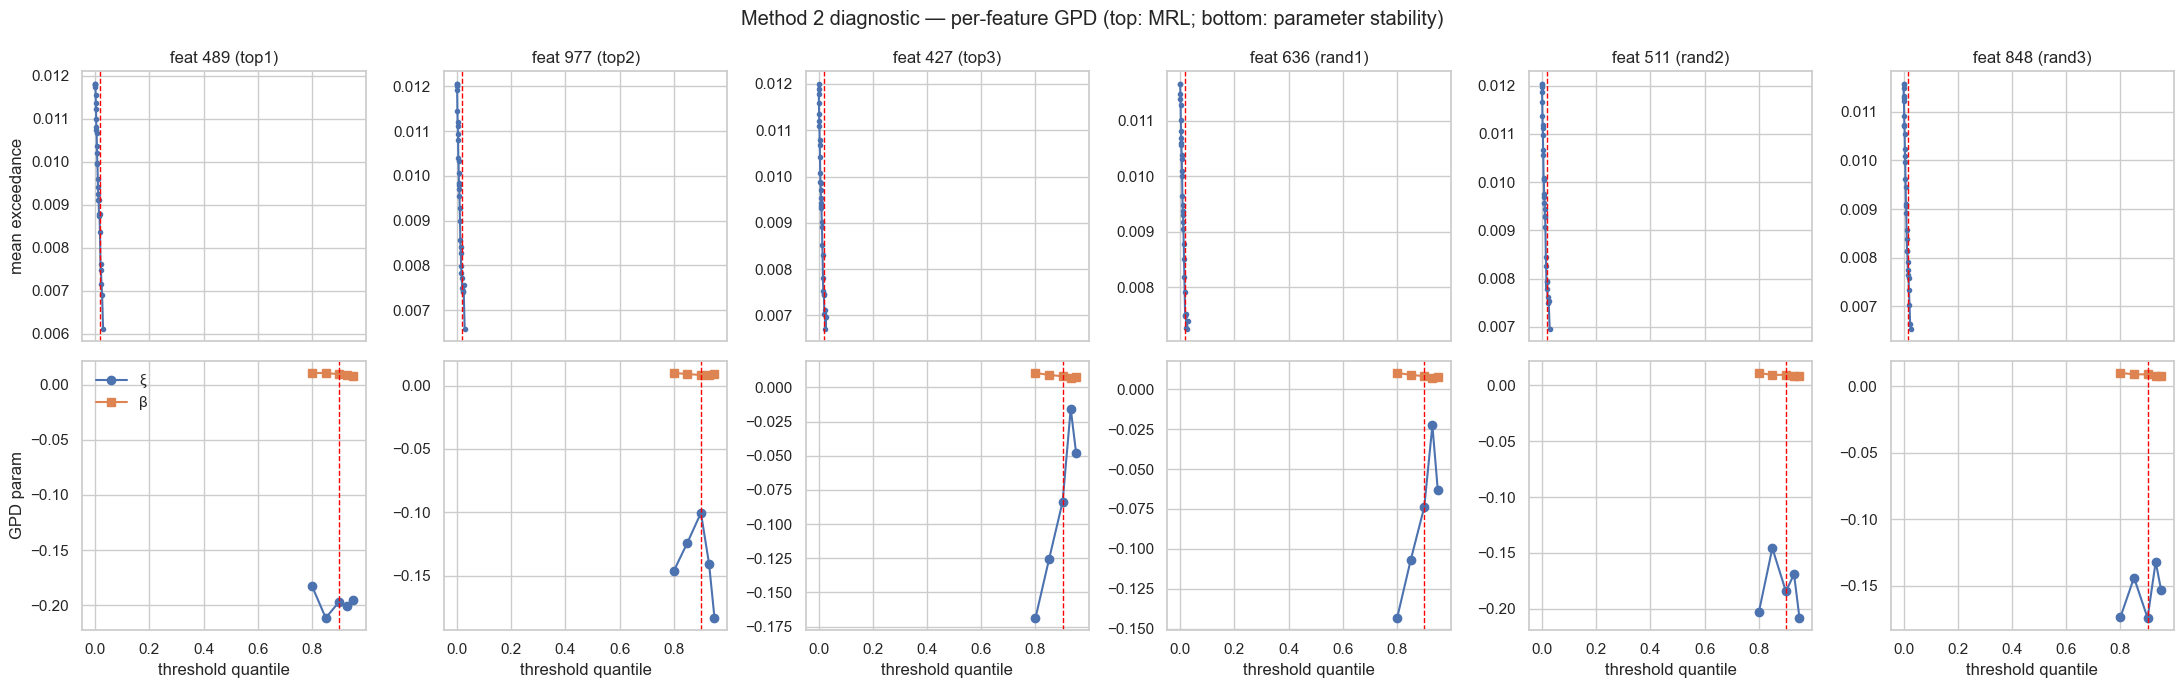

In [14]:
rng_pick = np.random.default_rng(0)
top_idx = np.argsort(T_obs_diag)[-3:]
rand_idx = rng_pick.choice(
    np.setdiff1d(np.arange(M_diag.shape[1]), top_idx),
    size=3, replace=False,
)
feat_idx = np.concatenate([top_idx, rand_idx])
labels = ['top1', 'top2', 'top3', 'rand1', 'rand2', 'rand3']

u_grid_q = np.array([0.80, 0.85, 0.90, 0.93, 0.95])

fig, axes = plt.subplots(2, 6, figsize=(22, 7), sharex='col')
for col, (j, lab) in enumerate(zip(feat_idx, labels)):
    null_vals = M_diag[:, j]
    # Mean-residual-life over a fine threshold grid.
    u_fine = np.quantile(null_vals, np.linspace(0.5, 0.97, 30))
    mrl = [np.mean(null_vals[null_vals > u] - u) if (null_vals > u).sum() >= 5 else np.nan
           for u in u_fine]
    axes[0, col].plot(u_fine, mrl, marker='o', ms=3)
    axes[0, col].axvline(np.quantile(null_vals, 0.90), color='red', ls='--', lw=1)
    axes[0, col].set_title(f'feat {j} ({lab})')
    if col == 0:
        axes[0, col].set_ylabel('mean exceedance')

    # Parameter-stability.
    xis, betas = [], []
    for q in u_grid_q:
        u = np.quantile(null_vals, q)
        ex = null_vals[null_vals > u] - u
        if ex.size < 10:
            xis.append(np.nan); betas.append(np.nan); continue
        try:
            xi, _, beta = genpareto.fit(ex, floc=0.0)
        except Exception:
            xi, beta = np.nan, np.nan
        xis.append(xi); betas.append(beta)
    ax = axes[1, col]
    ax.plot(u_grid_q, xis, marker='o', label='ξ')
    ax.plot(u_grid_q, betas, marker='s', label='β')
    ax.axvline(0.90, color='red', ls='--', lw=1)
    ax.set_xlabel('threshold quantile')
    if col == 0:
        ax.set_ylabel('GPD param')
        ax.legend(loc='upper left', frameon=False)
fig.suptitle('Method 2 diagnostic — per-feature GPD (top: MRL; bottom: parameter stability)')
fig.tight_layout()
plt.show()

Features with finite ξ fit: 1000 / 1000
Fraction with ξ ∈ [-0.5, 0.5]: 1.000
Median ξ: -0.128, IQR: [-0.168, -0.087]


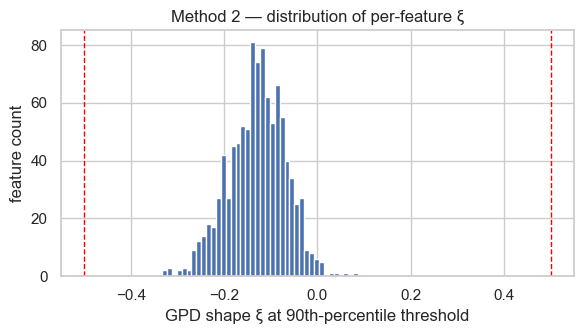

In [15]:
xi_at_90 = np.full(M_diag.shape[1], np.nan)
for j in range(M_diag.shape[1]):
    nv = M_diag[:, j]
    u = np.quantile(nv, 0.90)
    ex = nv[nv > u] - u
    if ex.size < 10:
        continue
    try:
        xi, _, _ = genpareto.fit(ex, floc=0.0)
        xi_at_90[j] = xi
    except Exception:
        pass

valid = np.isfinite(xi_at_90)
frac_in_band = float(((xi_at_90[valid] >= -0.5) & (xi_at_90[valid] <= 0.5)).mean())
print(f'Features with finite ξ fit: {int(valid.sum())} / {len(xi_at_90)}')
print(f'Fraction with ξ ∈ [-0.5, 0.5]: {frac_in_band:.3f}')
print(f'Median ξ: {np.nanmedian(xi_at_90):+.3f}, IQR: '
      f'[{np.nanpercentile(xi_at_90, 25):+.3f}, {np.nanpercentile(xi_at_90, 75):+.3f}]')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(xi_at_90[valid], bins=40)
ax.axvline(-0.5, color='red', ls='--', lw=1)
ax.axvline(0.5, color='red', ls='--', lw=1)
ax.set_xlabel('GPD shape ξ at 90th-percentile threshold')
ax.set_ylabel('feature count')
ax.set_title('Method 2 — distribution of per-feature ξ')
fig.tight_layout()
plt.show()

### Method 3 — location-scale invariance

Standardise per-feature: `S_{b,j} = (M_{b,j} − μ_j) / σ_j`. If the location-scale family assumption holds, all `S_{·,j}` should look like the pooled distribution.

In [16]:
mu = M_diag.mean(axis=0)
sigma = M_diag.std(axis=0, ddof=1)
alive = sigma > 0
S = (M_diag[:, alive] - mu[alive]) / sigma[alive]
S_pooled = S.ravel()
print(f'Standardised null: {S.shape}, alive features: {alive.sum()} / {M_diag.shape[1]}')

Standardised null: (2500, 1000), alive features: 1000 / 1000


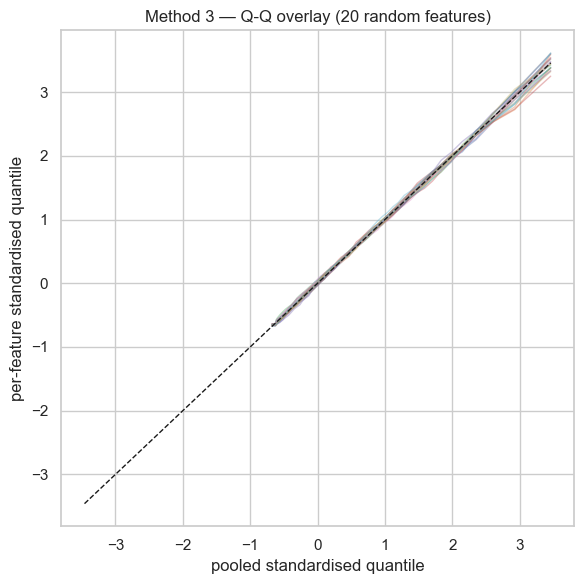

In [17]:
# Q-Q overlay for 20 random features against the pooled distribution.
rng_qq = np.random.default_rng(1)
pick = rng_qq.choice(S.shape[1], size=20, replace=False)
probs = np.linspace(0.01, 0.99, 99)
q_pool = np.quantile(S_pooled, probs)

fig, ax = plt.subplots(figsize=(6, 6))
for j in pick:
    q_j = np.quantile(S[:, j], probs)
    ax.plot(q_pool, q_j, alpha=0.4, lw=1)
lim = float(max(q_pool.max(), -q_pool.min()))
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
ax.set_xlabel('pooled standardised quantile')
ax.set_ylabel('per-feature standardised quantile')
ax.set_title('Method 3 — Q-Q overlay (20 random features)')
fig.tight_layout()
plt.show()

Per-feature skew:    mean=+1.848, std=0.085, pooled=+1.848
Per-feature kurt:    mean=+3.506, std=0.585, pooled=+3.506


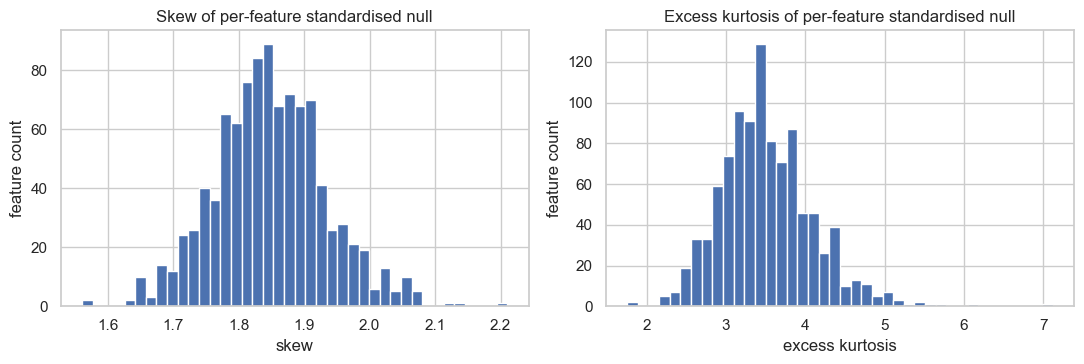

In [18]:
skews = skew(S, axis=0)
kurts = kurtosis(S, axis=0)
print(f'Per-feature skew:    mean={skews.mean():+.3f}, std={skews.std():.3f}, '
      f'pooled={skew(S_pooled):+.3f}')
print(f'Per-feature kurt:    mean={kurts.mean():+.3f}, std={kurts.std():.3f}, '
      f'pooled={kurtosis(S_pooled):+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].hist(skews, bins=40)
axes[0].set_title('Skew of per-feature standardised null')
axes[0].set_xlabel('skew'); axes[0].set_ylabel('feature count')
axes[1].hist(kurts, bins=40)
axes[1].set_title('Excess kurtosis of per-feature standardised null')
axes[1].set_xlabel('excess kurtosis'); axes[1].set_ylabel('feature count')
fig.tight_layout()
plt.show()

KS distance to pooled null — median=0.385, 90th pct=0.487, max=0.527


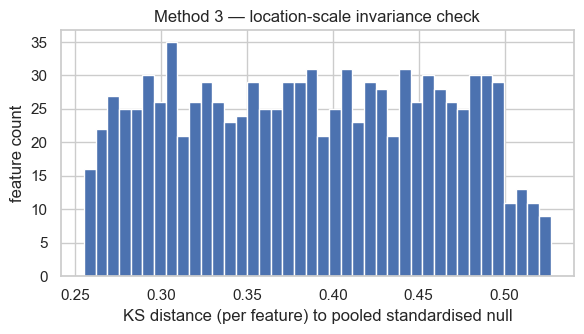

In [19]:
# Per-feature KS distance to the pooled standardised null.
pooled_sorted = np.sort(S_pooled)

def ks_to_pool(s):
    s_sorted = np.sort(s)
    n = s_sorted.size
    cdf_emp = (np.arange(1, n + 1)) / n
    cdf_pool = np.searchsorted(pooled_sorted, s_sorted, side='right') / pooled_sorted.size
    return float(np.max(np.abs(cdf_emp - cdf_pool)))

ks_vals = np.array([ks_to_pool(S[:, j]) for j in range(S.shape[1])])
print(f'KS distance to pooled null — median={np.median(ks_vals):.3f}, '
      f'90th pct={np.percentile(ks_vals, 90):.3f}, max={ks_vals.max():.3f}')

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(ks_vals, bins=40)
ax.set_xlabel('KS distance (per feature) to pooled standardised null')
ax.set_ylabel('feature count')
ax.set_title('Method 3 — location-scale invariance check')
fig.tight_layout()
plt.show()

### Method 4 — GPD asymptotics on the pooled tail

Method 4 also requires location-scale invariance (verified above for Method 3) plus GPD asymptotics on the pooled standardised null. We repeat the MRL and parameter-stability checks on the pooled distribution.

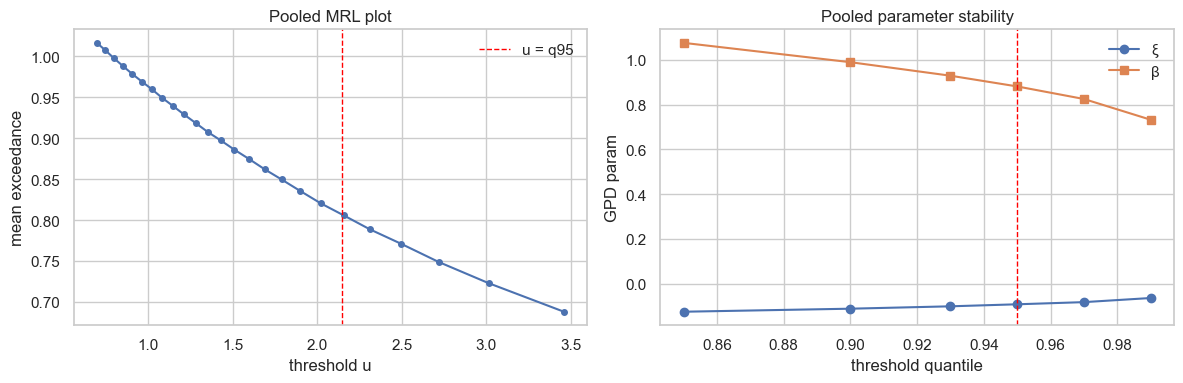

Pooled ξ by threshold quantile:
 u_quantile      xi   beta
       0.85 -0.1261 1.0761
       0.90 -0.1126 0.9897
       0.93 -0.1019 0.9292
       0.95 -0.0929 0.8813
       0.97 -0.0832 0.8251
       0.99 -0.0648 0.7324


In [20]:
u_grid_pool = np.quantile(S_pooled, np.linspace(0.80, 0.99, 25))
mrl_pool = []
for u in u_grid_pool:
    ex = S_pooled[S_pooled > u] - u
    mrl_pool.append(ex.mean() if ex.size >= 10 else np.nan)

u_q_grid = np.array([0.85, 0.90, 0.93, 0.95, 0.97, 0.99])
xis, betas = [], []
for q in u_q_grid:
    u = float(np.quantile(S_pooled, q))
    ex = S_pooled[S_pooled > u] - u
    try:
        xi, _, beta = genpareto.fit(ex, floc=0.0)
    except Exception:
        xi, beta = np.nan, np.nan
    xis.append(xi); betas.append(beta)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(u_grid_pool, mrl_pool, marker='o', ms=4)
axes[0].axvline(np.quantile(S_pooled, 0.95), color='red', ls='--', lw=1, label='u = q95')
axes[0].set_xlabel('threshold u'); axes[0].set_ylabel('mean exceedance')
axes[0].set_title('Pooled MRL plot'); axes[0].legend(frameon=False)

axes[1].plot(u_q_grid, xis, marker='o', label='ξ')
axes[1].plot(u_q_grid, betas, marker='s', label='β')
axes[1].axvline(0.95, color='red', ls='--', lw=1)
axes[1].set_xlabel('threshold quantile'); axes[1].set_ylabel('GPD param')
axes[1].set_title('Pooled parameter stability'); axes[1].legend(frameon=False)
fig.tight_layout()
plt.show()

print('Pooled ξ by threshold quantile:')
print(pd.DataFrame({'u_quantile': u_q_grid, 'xi': xis, 'beta': betas}).round(4).to_string(index=False))

## Summary

Read off from the tables and plots above:

* **Agreement with adaptive** — see `real_table` and `sim_table`. Higher Spearman of p / q against adaptive and higher Jaccard on the rejected set indicate closer agreement.
* **Method 2 (per-feature GPD)** — the parameter-stability and MRL plots, plus the histogram of per-feature `ξ` at the 90th-percentile threshold, indicate whether GPD asymptotics are reasonable. Look for `ξ` concentrated near zero (light-tailed) and stable across thresholds.
* **Method 3 (pooled empirical)** — the Q-Q overlay, skew/kurtosis histograms, and per-feature KS distances together quantify the location-scale invariance assumption. Tight Q-Q lines, low KS median, and low cross-feature variance in skew/kurtosis support the assumption.
* **Method 4 (pooled + GPD)** — inherits Method 3's verdict and additionally requires GPD asymptotics on the pooled tail (MRL and pooled parameter-stability plots).

The most defensible default for production is the cheapest method whose assumptions look satisfied by these diagnostics; the adaptive variant remains the safest fallback for ranking the very tail features where even mild assumption violations matter.